# Monthly Technical Strategy — Rebalancing + Belka Tax (GPW 2000–2025)

Technical scoring (RSI, MACD, Stochastic, CCI, ROC, EMA) combined
with a monthly decision cycle and a 10-stock portfolio.

**Three variants:** different entry/exit thresholds (enter/sell percent).
**Belka Tax (19% capital gains tax)** applied at each profitable sale.

**Data:** `open_prices.csv` (GPW, ~354 stocks, 2000–2025)


---
## Algorithm Description

### 1. Technical Scoring (Monthly)

At the end of each month we compute a score [0–1] for each stock:

| Indicator | Weight | Note |
|----------|--------|------|
| RSI(14) | 20% | from daily prices, value at month-end |
| MACD histogram | 20% | EMA12 − EMA26 − Signal(9) |
| Stochastic %K(14) | 10% | |
| CCI(20) | 10% | |
| ROC(10) | 20% | Rate of Change |
| EMA20 > EMA50 | 10% | binary signal |
| EMA20/EMA50 ratio | 10% | trend strength |

### 2. Portfolio Logic (Monthly)

The score is read at the end of month *t*; the resulting trades execute at month *t+1* prices — the first point at which the signal is actionable, so there is **no lookahead bias**.

Each rebalance:
1. **Sell** positions with score below exit threshold → Belka tax on gain
2. **Fill** portfolio to 10 stocks — buy highest-scoring stocks above entry threshold

**Capital allocation:** equal-weight across all held positions.

---

### Three Variants

| Variant | Entry | Exit | Max positions |
|---------|-------|------|---------------|
| V1 Standard    | 60%  | 40%  | 10 |
| V2 Selective   | 70%  | 35%  | 10 |
| V3 Wide        | 50%  | 30%  | 10 |

---

### Limitations

- Monthly rebalancing only — no intraday stop-loss
- Signal-to-execution lag of one month removes lookahead bias but does not capture intra-month moves
- Belka tax applied per transaction (realistic Polish tax treatment)
- Survivorship bias: universe = stocks listed today; delisted names absent
- No slippage modelled

*Analysis and code: Python + Claude AI*


## 0. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

OUT = Path('charts_tech_monthly')
OUT.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 200,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.titlesize': 13, 'axes.labelsize': 11,
})
COLORS = {'s1': '#E74C3C', 's2': '#3498DB', 's3': '#2ECC71',
          'buy': '#27AE60', 'sell': '#E74C3C'}
print('Setup OK —', OUT.resolve())


Setup OK — D:\MOJE\PROJEKTY\stock-technical-analysis\technical-monthly\charts_tech_monthly


## 1. Load Data

In [2]:
# Load daily prices — needed for technical indicators
df_daily = pd.read_csv('open_prices.csv', index_col='Date', parse_dates=True)
df_daily = df_daily.sort_index()
df_daily = df_daily.loc[:, df_daily.notna().sum() >= 100]

# Monthly prices (last day of month) — for portfolio valuation and transactions
df_monthly = df_daily.resample('M').last()
df_monthly = df_monthly.dropna(axis=1, how='all')

print(f'Zakres:           {df_daily.index[0].date()} – {df_daily.index[-1].date()}')
print(f'Dni handlowych:   {len(df_daily)}')
print(f'Miesięcy:         {len(df_monthly)}')
print(f'Spółek (monthly): {df_monthly.shape[1]}')


Zakres:           2000-01-03 – 2025-09-18
Dni handlowych:   6670
Miesięcy:         309
Spółek (monthly): 350


## 2. Technical Scoring

In [3]:
# ── Technical indicators (no external libraries) ───────────────────────
def rsi(close, w=14):
    d = close.diff()
    g = d.clip(lower=0).rolling(w).mean()
    l = (-d.clip(upper=0)).rolling(w).mean()
    return 100 - 100 / (1 + g / l.replace(0, np.nan))

def macd_hist(close, fast=12, slow=26, sig=9):
    m = close.ewm(span=fast, adjust=False).mean() - close.ewm(span=slow, adjust=False).mean()
    return m - m.ewm(span=sig, adjust=False).mean()

def stoch(close, w=14):
    lo, hi = close.rolling(w).min(), close.rolling(w).max()
    return (close - lo) / (hi - lo).replace(0, np.nan) * 100

def cci(close, w=20):
    sma = close.rolling(w).mean()
    mad = close.rolling(w).apply(lambda x: np.mean(np.abs(x - x.mean())), raw=True)
    return (close - sma) / (0.015 * mad.replace(0, np.nan))

def roc(close, w=10):
    return (close / close.shift(w) - 1) * 100

def norm_clip(s, lo, hi):
    return ((s - lo) / (hi - lo)).clip(0, 1)

def build_daily_scores(df):
    """Score dzienny [0–1] dla każdej spółki."""
    r   = rsi(df)
    m   = macd_hist(df)
    st  = stoch(df)
    c   = cci(df)
    ro  = roc(df)
    e20 = df.ewm(span=20, adjust=False).mean()
    e50 = df.ewm(span=50, adjust=False).mean()
    q05 = lambda x: x.stack().quantile(0.05)
    q95 = lambda x: x.stack().quantile(0.95)
    return (
        0.20 * norm_clip(r,   0,       100) +
        0.20 * norm_clip(m,   q05(m),  q95(m)) +
        0.10 * norm_clip(st,  0,       100) +
        0.10 * norm_clip(c,  -200,     200) +
        0.20 * norm_clip(ro,  q05(ro), q95(ro)) +
        0.10 * (e20 > e50).astype(float) +
        0.10 * norm_clip(e20 / e50.replace(0, np.nan) - 1, -0.1, 0.1)
    )

print('Obliczam dzienny scoring (może chwilę potrwać)...')
score_daily = build_daily_scores(df_daily)

# Resample to months — take value from last day of month
score_monthly = score_daily.resample('M').last()
# Przeliczamy na procenty [0–100] — ten sam format co strategia momentum
percent_monthly = score_monthly * 100

print(f'Score miesięczny: {percent_monthly.shape}')
print('Przykład (ostatnie 3 miesiące, 5 spółek):')
print(percent_monthly.iloc[-3:, :5].round(1))


Obliczam dzienny scoring (może chwilę potrwać)...


Score miesięczny: (309, 350)
Przykład (ostatnie 3 miesiące, 5 spółek):
            06N.WA  08N.WA  11B.WA  1AT.WA  3RG.WA
Date                                              
2025-07-31    33.5    24.5    53.4    25.9    78.6
2025-08-31    32.5    34.9    46.7    77.8    38.2
2025-09-30    73.2    41.9    51.7    37.8    67.9


## 3. Backtest Engine — Monthly Rebalancing with Belka Tax

In [4]:
def run_monthly_tech_backtest(price_monthly, percent_monthly, cfg):
    """
    Miesięczny rebalans z podatkiem Belki.

    Brak lookahead bias: scoring liczony jest na koniec miesiąca
    `signal_date`, a transakcje wykonywane są po cenach następnego
    miesiąca (`trade_date`).

    cfg: start_capital, max_size, enter_pct, sell_pct, tax_rate
    """
    cash      = cfg['start_capital']
    positions = {}   # ticker -> {shares, avg_cost}
    trades    = []
    tax_recs  = []
    equity    = []

    common = price_monthly.index.intersection(percent_monthly.index)
    dates  = list(common)

    # iterujemy parami: sygnał z `signal_date`, egzekucja po cenach `trade_date`
    for signal_date, trade_date in zip(dates[:-1], dates[1:]):
        prices   = price_monthly.loc[trade_date]      # ceny egzekucji
        percents = percent_monthly.loc[signal_date].dropna()  # sygnał z poprz. miesiąca
        # restrict to stocks with a price in the execution month
        percents = percents[percents.index.isin(prices.dropna().index)]

        # ── SELL: score below exit threshold ───────────────────────────
        for ticker in list(positions):
            if ticker not in percents.index:
                continue
            if percents[ticker] < cfg['sell_pct']:
                pos      = positions.pop(ticker)
                price    = prices[ticker]
                proceeds = pos['shares'] * price
                gain     = proceeds - pos['shares'] * pos['avg_cost']
                tax      = round(cfg['tax_rate'] * gain, 2) if gain > 0 else 0.0
                cash    += proceeds - tax
                trades.append(dict(date=trade_date, action='SELL', ticker=ticker,
                                   price=price, shares=pos['shares'],
                                   proceeds=proceeds, tax=tax))
                if tax > 0:
                    tax_recs.append(dict(date=trade_date, tax=tax))

        # ── TARGET LIST ──────────────────────────────────────────────────
        eligible = percents[percents >= cfg['enter_pct']].sort_values(ascending=False)
        target   = list(eligible.index[:cfg['max_size']])
        # fallback — fill if too few candidates above entry threshold
        if len(target) < cfg['max_size']:
            rest   = percents.drop(index=[t for t in target if t in percents.index])
            target += list(rest.sort_values(ascending=False).index)[:cfg['max_size'] - len(target)]

        # ── BUY: fill empty slots ───────────────────────────────────────
        slots      = cfg['max_size'] - len(positions)
        new_tickers = [t for t in target if t not in positions][:slots]
        if new_tickers and cash > 0:
            per_slot = cash / max(slots, 1)
            for ticker in new_tickers:
                price  = prices.get(ticker, np.nan)
                if np.isnan(price) or price <= 0:
                    continue
                shares = int(np.floor(min(per_slot, cash) / price))
                if shares <= 0:
                    continue
                cost   = shares * price
                cash  -= cost
                positions[ticker] = {'shares': shares, 'avg_cost': price}
                trades.append(dict(date=trade_date, action='BUY', ticker=ticker,
                                   price=price, shares=shares,
                                   proceeds=cost, tax=0))

        # ── TOP-UP: reszta cash do najbardziej niedofinansowanej ─────────
        if positions and cash > 1:
            mv     = {t: positions[t]['shares'] * prices.get(t, 0) for t in positions}
            worst  = min(mv, key=mv.get)
            price  = prices.get(worst, np.nan)
            if not np.isnan(price) and price > 0:
                shares = int(np.floor(cash / price))
                if shares > 0:
                    cost  = shares * price
                    cash -= cost
                    p    = positions[worst]
                    p['avg_cost'] = (p['shares']*p['avg_cost'] + cost) / (p['shares'] + shares)
                    p['shares']  += shares
                    trades.append(dict(date=trade_date, action='BUY', ticker=worst,
                                       price=price, shares=shares,
                                       proceeds=cost, tax=0))

        # ── EQUITY SNAPSHOT ──────────────────────────────────────────────
        port_val = sum(
            positions[t]['shares'] * prices.get(t, positions[t]['avg_cost'])
            for t in positions
        )
        equity.append(dict(date=trade_date, capital=cash + port_val,
                           cash=cash, n_positions=len(positions)))

    cap_df    = pd.DataFrame(equity).set_index('date')
    cap_df.index = pd.to_datetime(cap_df.index)
    trades_df = pd.DataFrame(trades)
    tax_df    = pd.DataFrame(tax_recs)
    return cap_df, trades_df, tax_df

print('Silnik gotowy.')

Silnik gotowy.


## 4. Run — Three Variants

In [5]:
configs = {
    'S1 Konserwatywny (80/40)': dict(
        start_capital=10_000, max_size=10, tax_rate=0.19,
        enter_pct=80, sell_pct=40),
    'S2 Standardowy (60/30)':   dict(
        start_capital=10_000, max_size=10, tax_rate=0.19,
        enter_pct=60, sell_pct=30),
    'S3 Agresywny (40/20)':     dict(
        start_capital=10_000, max_size=10, tax_rate=0.19,
        enter_pct=40, sell_pct=20),
}
COLORS_LIST = [COLORS['s1'], COLORS['s2'], COLORS['s3']]

results = {}
for name, cfg in configs.items():
    print(f'Backtesting {name}...')
    cap, trades, tax = run_monthly_tech_backtest(df_monthly, percent_monthly, cfg)
    results[name] = dict(cap=cap, trades=trades, tax=tax, cfg=cfg)

    final   = cap['capital'].iloc[-1]
    ret     = (final / cfg['start_capital'] - 1) * 100
    dd      = ((cap['capital'] - cap['capital'].cummax()) / cap['capital'].cummax() * 100).min()
    ntxn    = len(trades[trades['action']=='BUY']) if not trades.empty else 0
    ttax    = tax['tax'].sum() if not tax.empty else 0
    print(f'  Kapitał: {final:>10,.0f} PLN  Zwrot: {ret:>+8.1f}%  '
          f'MaxDD: {dd:>6.1f}%  BUY: {ntxn:>4}  Podatek: {ttax:>8,.0f} PLN')


Backtesting S1 Konserwatywny (80/40)...


  Kapitał:    315,908 PLN  Zwrot:  +3059.1%  MaxDD:  -72.0%  BUY: 1042  Podatek:  201,643 PLN
Backtesting S2 Standardowy (60/30)...


  Kapitał:    194,795 PLN  Zwrot:  +1847.9%  MaxDD:  -75.2%  BUY:  579  Podatek:   82,276 PLN
Backtesting S3 Agresywny (40/20)...
  Kapitał:    168,114 PLN  Zwrot:  +1581.1%  MaxDD:  -73.1%  BUY:  218  Podatek:   49,152 PLN


## 5. Visualizations

> Saved to `charts_tech_monthly/`

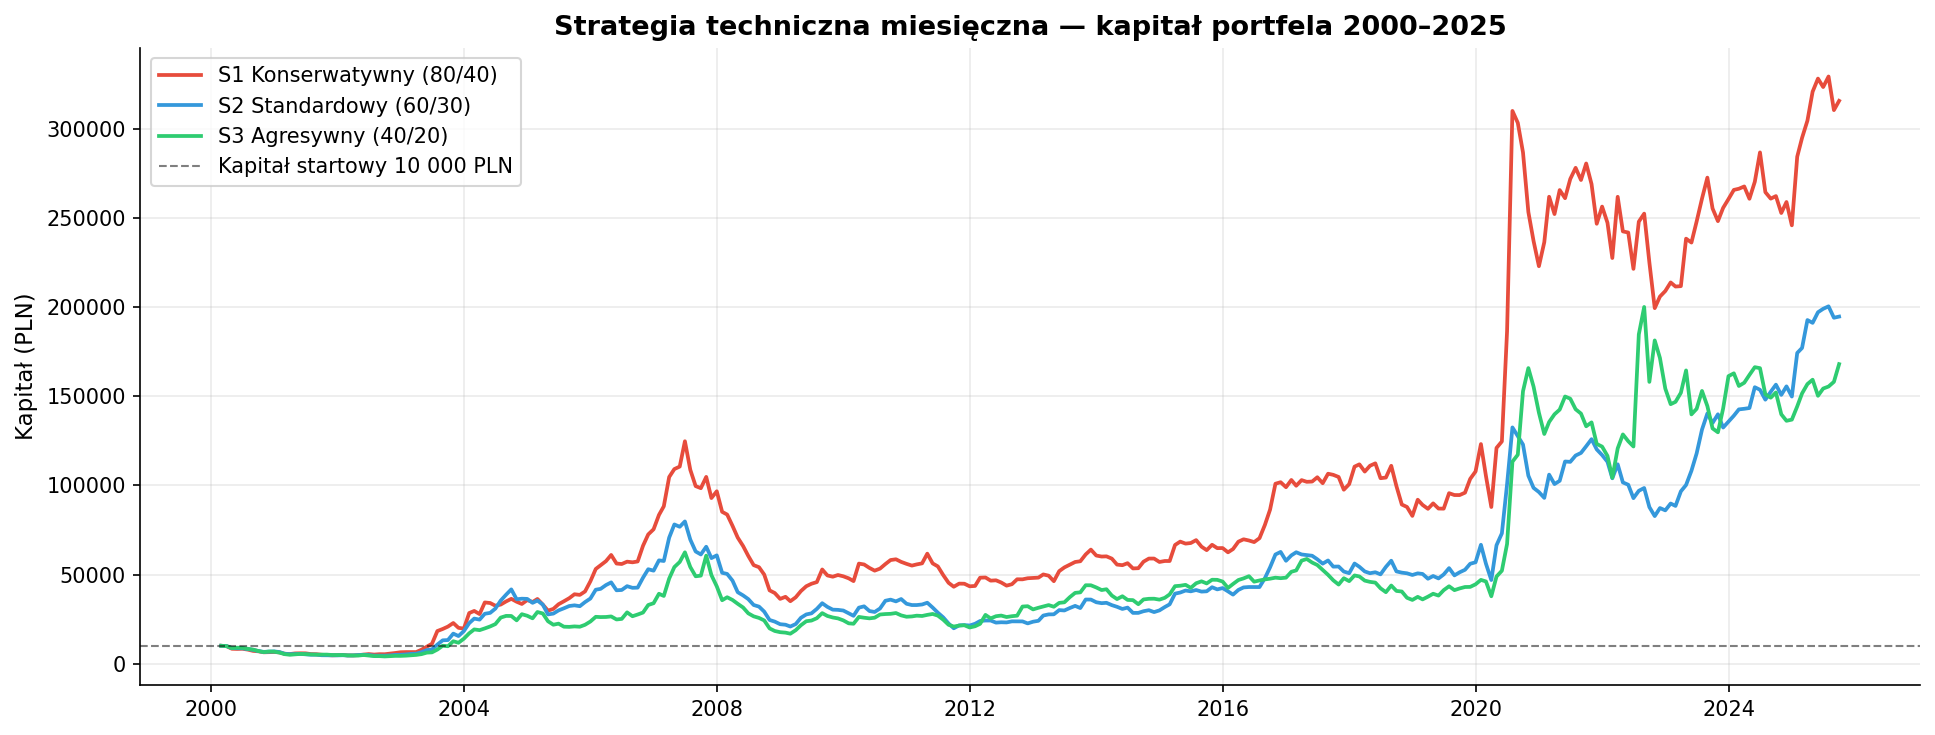

Saved: m01_kapital_porownanie.png


In [6]:
# ── Fig 1: Portfolio capital ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
for (name, res), col in zip(results.items(), COLORS_LIST):
    ax.plot(res['cap'].index, res['cap']['capital'],
            label=name, color=col, linewidth=1.8)
ax.axhline(10_000, color='black', linestyle='--', linewidth=1,
           alpha=0.5, label='Kapitał startowy 10 000 PLN')
ax.set_title('Strategia techniczna miesięczna — kapitał portfela 2000–2025',
             fontweight='bold')
ax.set_ylabel('Kapitał (PLN)')
ax.legend()
plt.tight_layout()
fig.savefig(OUT / 'm01_kapital_porownanie.png', bbox_inches='tight')
plt.show()
print('Saved: m01_kapital_porownanie.png')


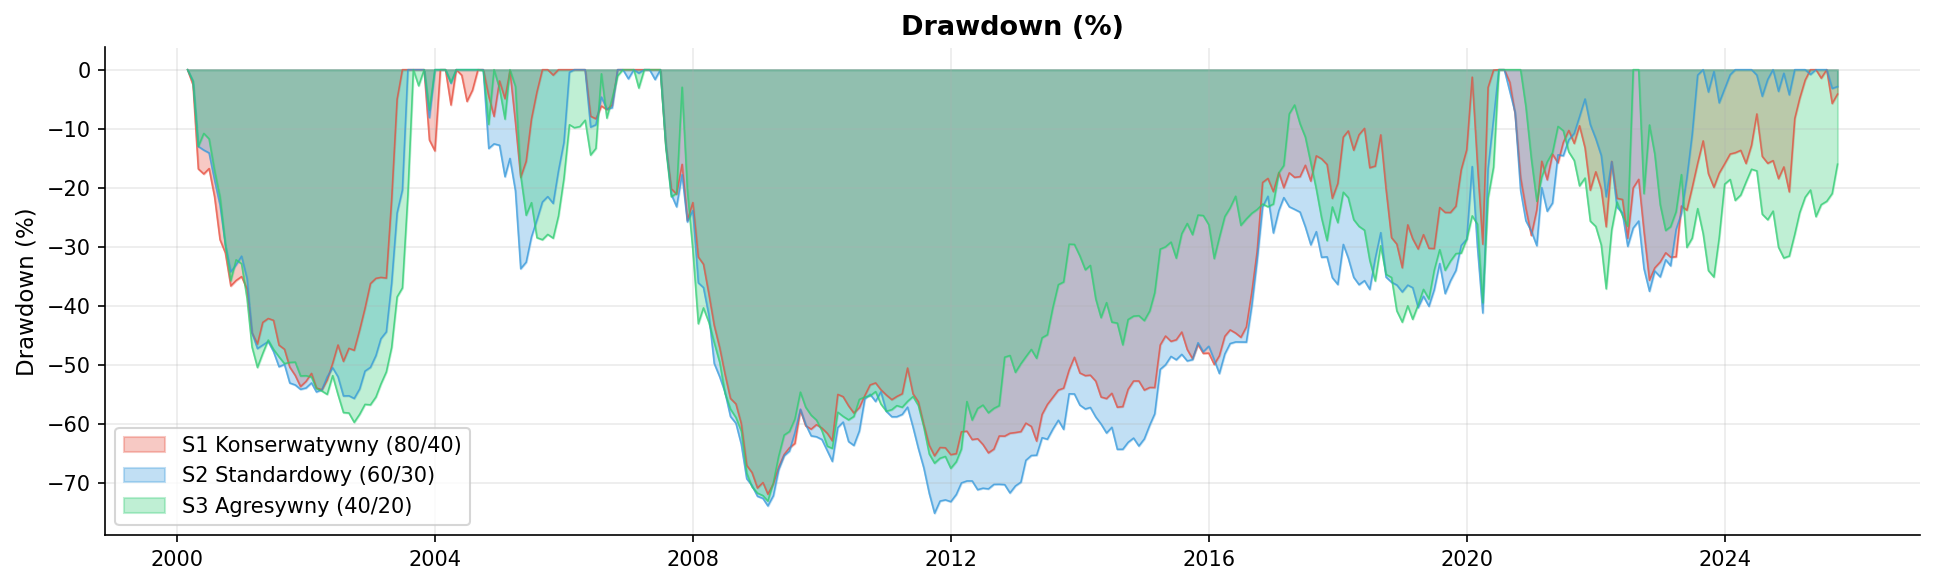

Saved: m02_drawdown.png


In [7]:
# ── Fig 2: Drawdown ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
for (name, res), col in zip(results.items(), COLORS_LIST):
    cap = res['cap']['capital']
    dd  = (cap - cap.cummax()) / cap.cummax() * 100
    ax.fill_between(dd.index, dd, 0, alpha=0.3, color=col, label=name)
    ax.plot(dd.index, dd, color=col, linewidth=0.8, alpha=0.7)
ax.set_title('Drawdown (%)', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend()
plt.tight_layout()
fig.savefig(OUT / 'm02_drawdown.png', bbox_inches='tight')
plt.show()
print('Saved: m02_drawdown.png')


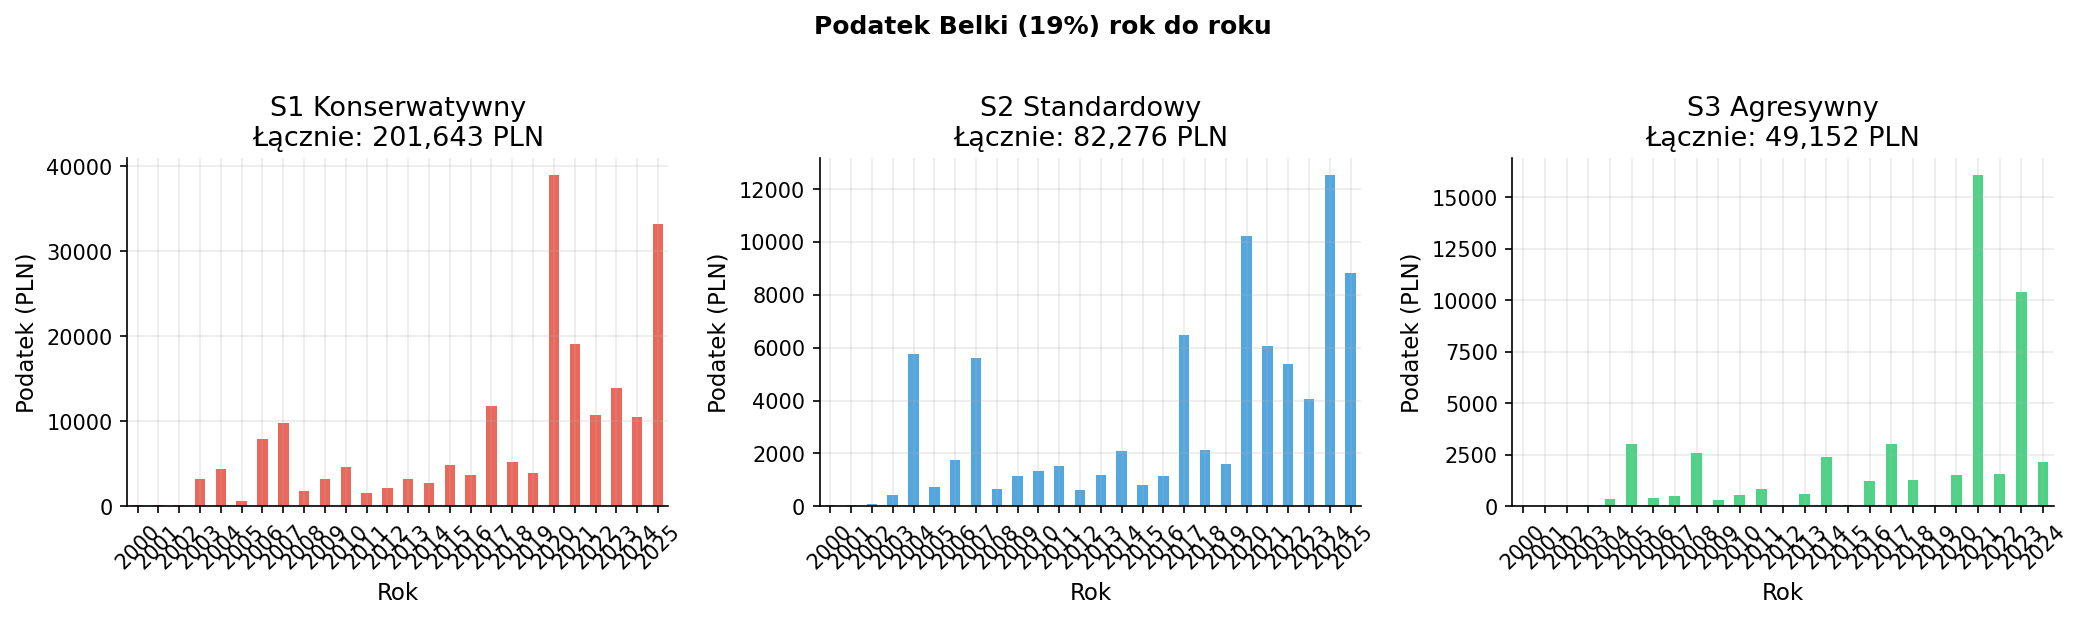

Saved: m03_podatki_roczne.png


In [8]:
# ── Fig 3: Podatki rok do roku ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, res), col in zip(axes, results.items(), COLORS_LIST):
    tax_df = res['tax']
    if not tax_df.empty:
        tax_df = tax_df.copy()
        tax_df['date'] = pd.to_datetime(tax_df['date'])
        by_year = tax_df.set_index('date').resample('Y')['tax'].sum()
        by_year.index = by_year.index.year
        by_year.plot(kind='bar', ax=ax, color=col, alpha=0.85)
    total = tax_df['tax'].sum() if not tax_df.empty else 0
    short = name.split('(')[0].strip()
    ax.set_title(f'{short}\nŁącznie: {total:,.0f} PLN')
    ax.set_xlabel('Rok')
    ax.set_ylabel('Podatek (PLN)')
    ax.tick_params(axis='x', rotation=45)
fig.suptitle('Podatek Belki (19%) rok do roku', fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUT / 'm03_podatki_roczne.png', bbox_inches='tight')
plt.show()
print('Saved: m03_podatki_roczne.png')


Obliczam wersje bez podatku dla porównania...


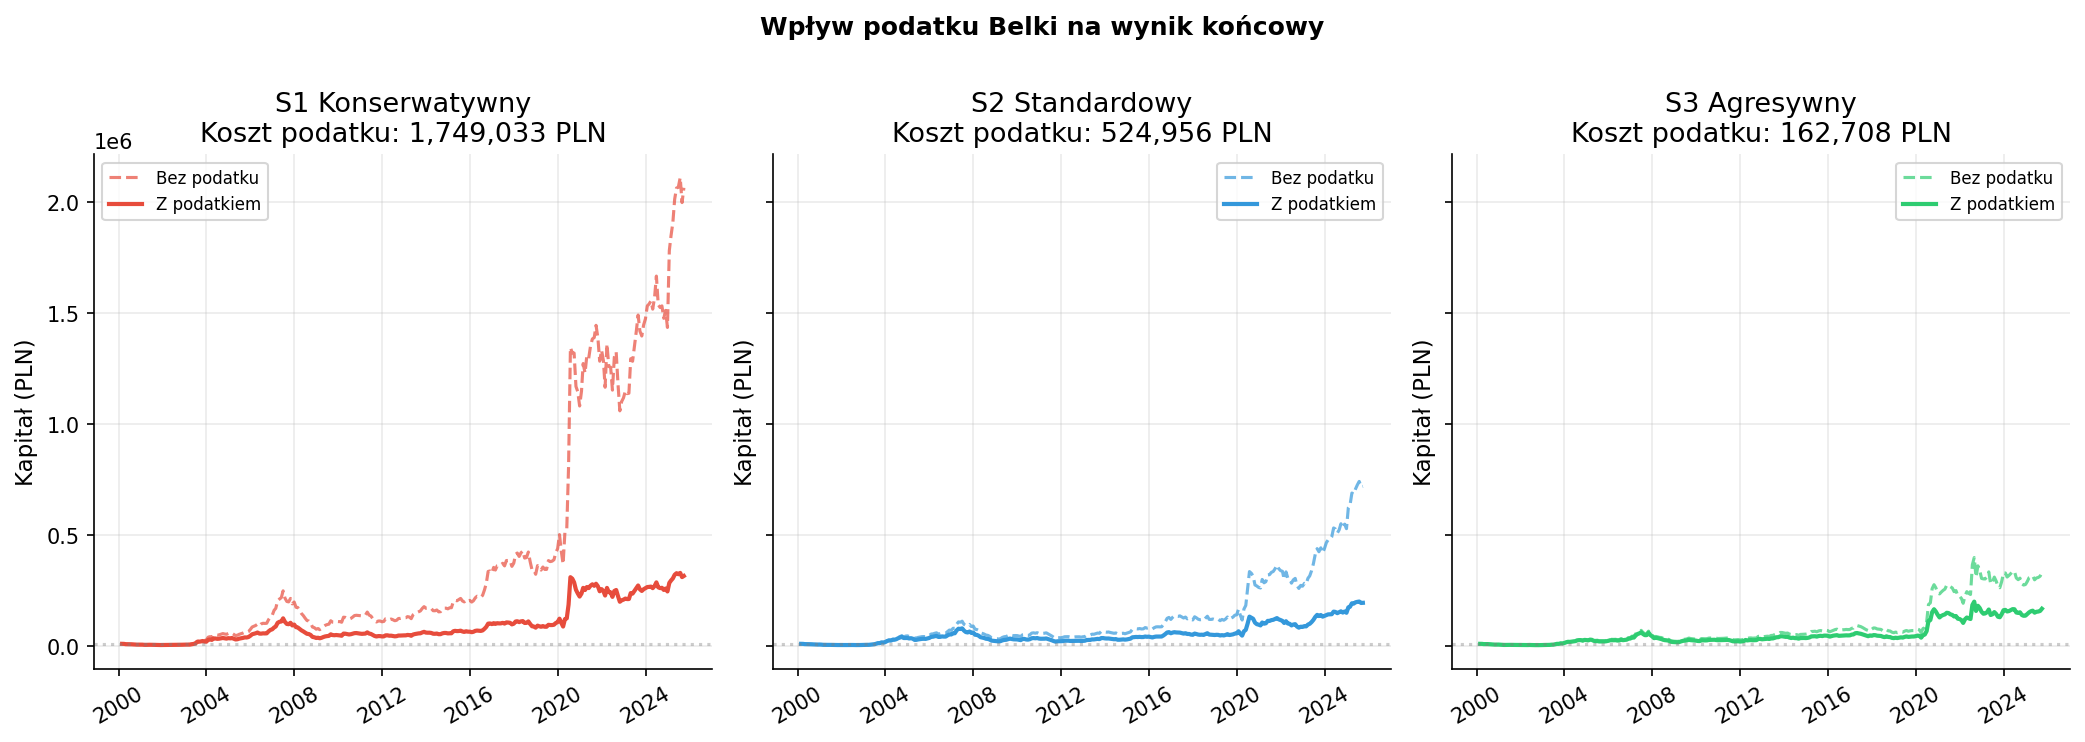

Saved: m04_brutto_vs_netto.png


In [9]:
# ── Fig 4: Gross capital (pre-tax) vs net capital (post-tax) ────────────
# Tax-free version — for comparison
print('Obliczam wersje bez podatku dla porównania...')
results_notax = {}
for name, cfg in configs.items():
    cfg_notax = {**cfg, 'tax_rate': 0.0}
    cap, _, _ = run_monthly_tech_backtest(df_monthly, percent_monthly, cfg_notax)
    results_notax[name] = cap

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, (name, res), col in zip(axes, results.items(), COLORS_LIST):
    cap_tax   = res['cap']['capital']
    cap_notax = results_notax[name]['capital']
    ax.plot(cap_notax.index, cap_notax, color=col, linewidth=1.5,
            linestyle='--', alpha=0.7, label='Bez podatku')
    ax.plot(cap_tax.index, cap_tax, color=col, linewidth=2, label='Z podatkiem')
    ax.axhline(10_000, color='gray', linestyle=':', alpha=0.4)
    final_tax   = cap_tax.iloc[-1]
    final_notax = cap_notax.iloc[-1]
    diff = final_notax - final_tax
    short = name.split('(')[0].strip()
    ax.set_title(f'{short}\nKoszt podatku: {diff:,.0f} PLN')
    ax.set_ylabel('Kapitał (PLN)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Wpływ podatku Belki na wynik końcowy', fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'm04_brutto_vs_netto.png', bbox_inches='tight')
plt.show()
print('Saved: m04_brutto_vs_netto.png')


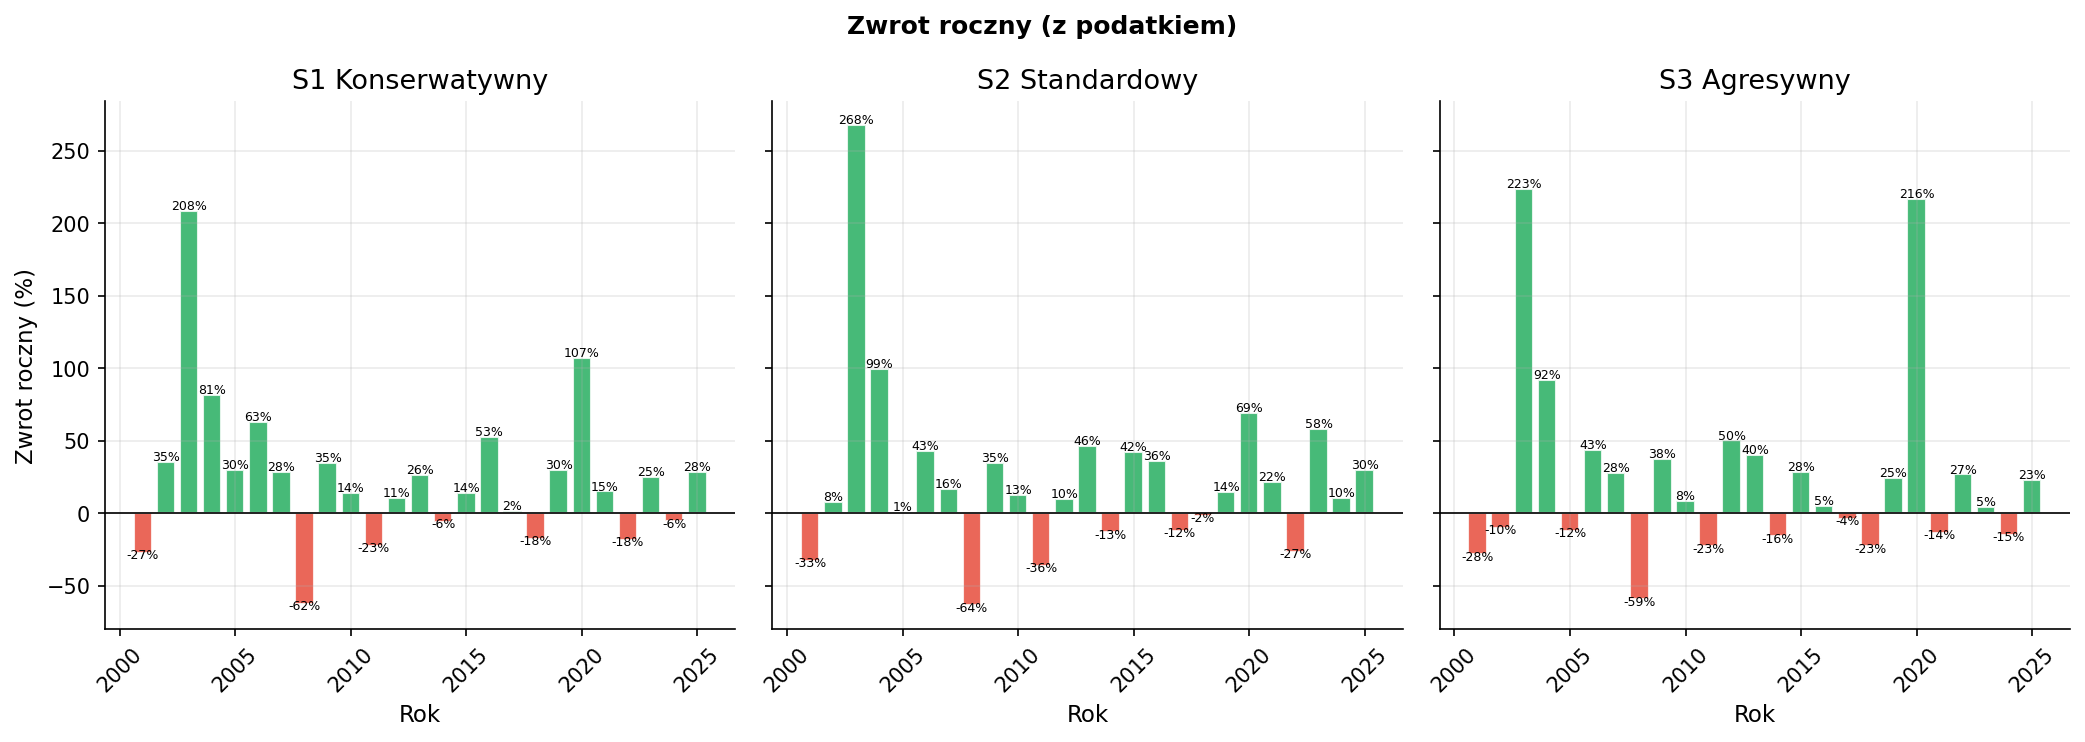

Saved: m05_zwrot_roczny.png


In [10]:
# ── Fig 5: Zwrot roczny ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, (name, res), col in zip(axes, results.items(), COLORS_LIST):
    cap    = res['cap']['capital']
    annual = cap.resample('Y').last().pct_change().dropna() * 100
    annual.index = annual.index.year
    bar_colors = [COLORS['buy'] if v >= 0 else COLORS['sell'] for v in annual]
    bars = ax.bar(annual.index, annual.values, color=bar_colors,
                 alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    short = name.split('(')[0].strip()
    ax.set_title(short)
    ax.set_xlabel('Rok')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, annual.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + (1 if val >= 0 else -4),
                f'{val:.0f}%', ha='center', fontsize=6)
axes[0].set_ylabel('Zwrot roczny (%)')
fig.suptitle('Zwrot roczny (z podatkiem)', fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'm05_zwrot_roczny.png', bbox_inches='tight')
plt.show()
print('Saved: m05_zwrot_roczny.png')


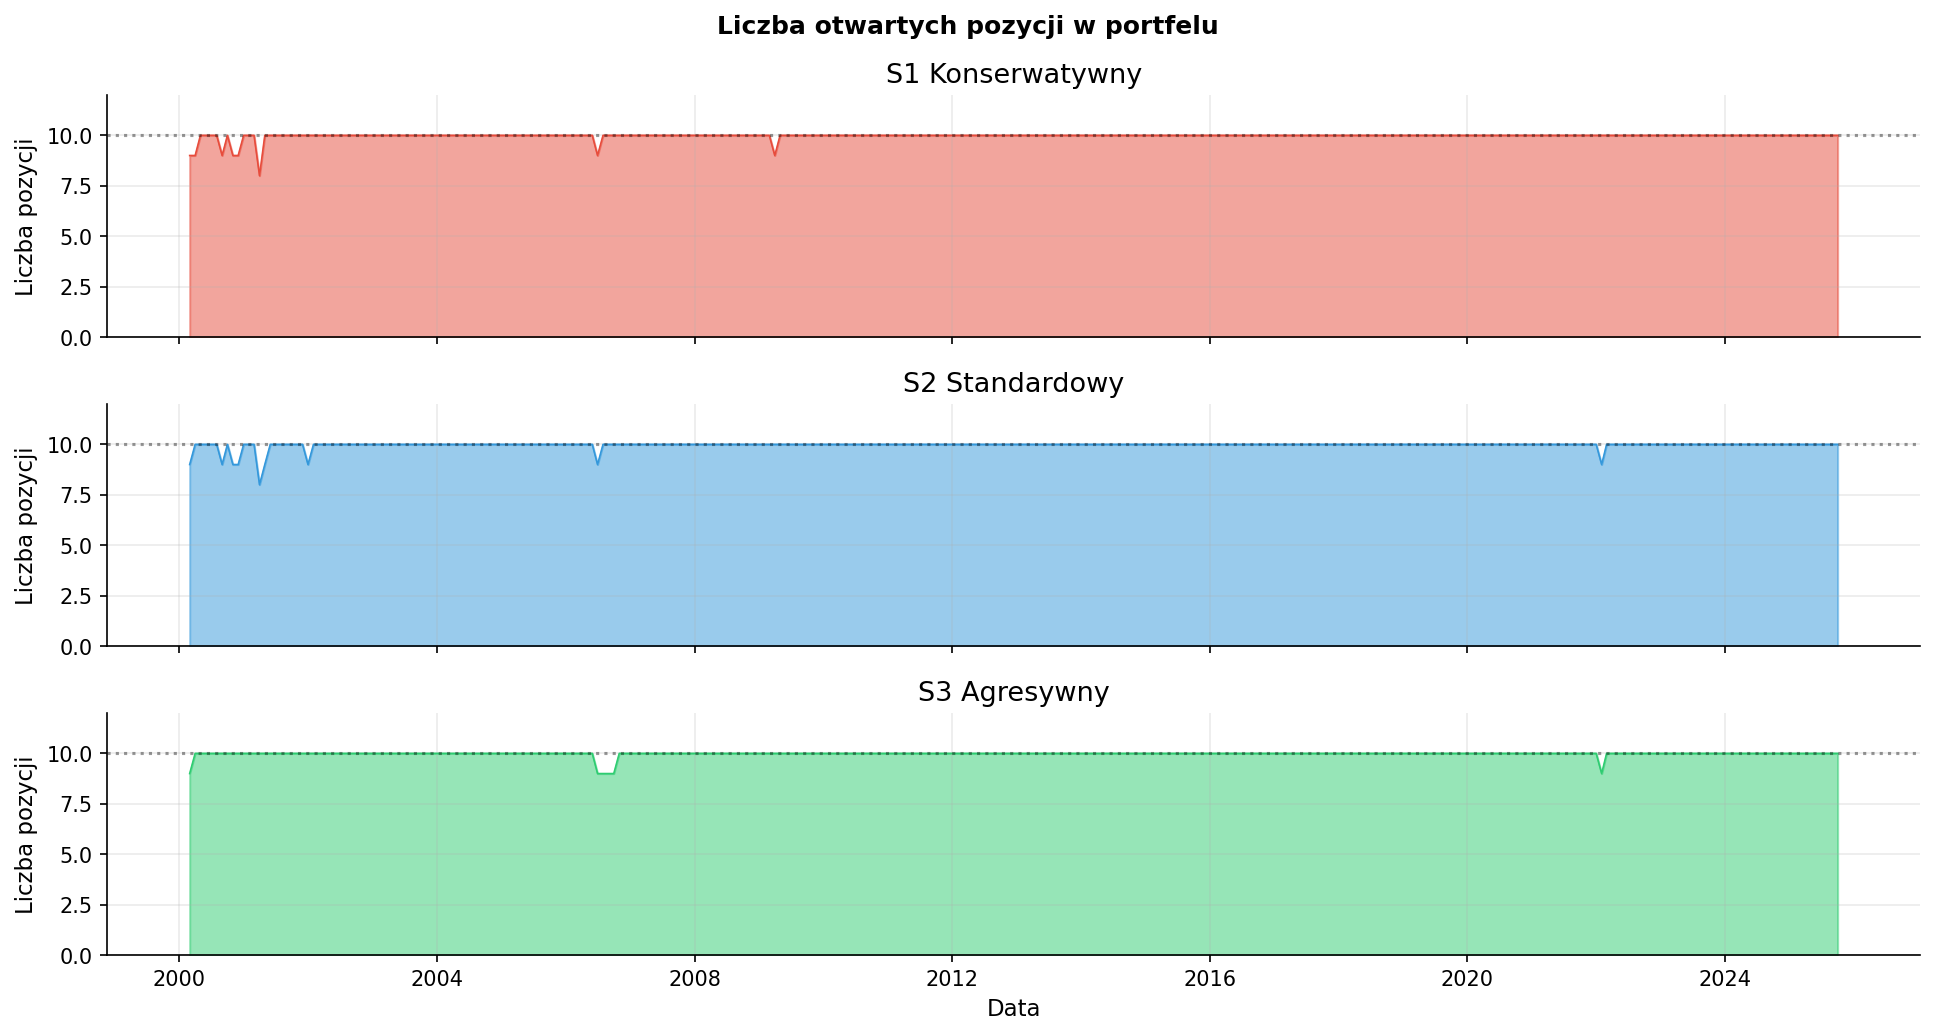

Saved: m06_liczba_pozycji.png


In [11]:
# ── Fig 6: Liczba pozycji w portfelu ────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
for ax, (name, res), col in zip(axes, results.items(), COLORS_LIST):
    ax.fill_between(res['cap'].index, res['cap']['n_positions'],
                    alpha=0.5, color=col)
    ax.plot(res['cap'].index, res['cap']['n_positions'], color=col, linewidth=0.8)
    ax.axhline(10, color='black', linestyle=':', alpha=0.4)
    ax.set_ylim(0, 12)
    ax.set_ylabel('Liczba pozycji')
    short = name.split('(')[0].strip()
    ax.set_title(short)
axes[-1].set_xlabel('Data')
fig.suptitle('Liczba otwartych pozycji w portfelu', fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'm06_liczba_pozycji.png', bbox_inches='tight')
plt.show()
print('Saved: m06_liczba_pozycji.png')


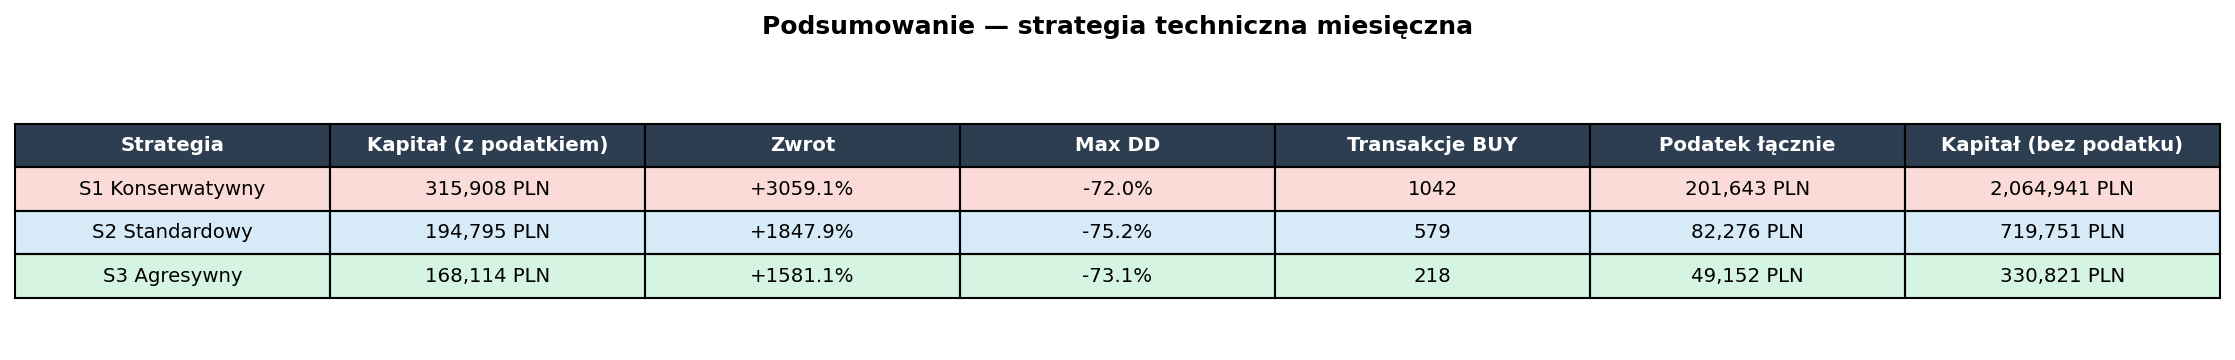

Saved: m07_tabela.png


In [12]:
# ── Fig 7: Summary table ────────────────────────────────────────────────
rows = []
for name, res in results.items():
    cap   = res['cap']['capital']
    final = cap.iloc[-1]
    ret   = (final / 10_000 - 1) * 100
    dd    = ((cap - cap.cummax()) / cap.cummax() * 100).min()
    td    = res['trades']
    ntxn  = len(td[td['action']=='BUY']) if not td.empty else 0
    ttax  = res['tax']['tax'].sum() if not res['tax'].empty else 0
    # bez podatku
    final_gross = results_notax[name]['capital'].iloc[-1]
    short = name.split('(')[0].strip()
    rows.append([short, f'{final:,.0f} PLN', f'{ret:+.1f}%',
                 f'{dd:.1f}%', str(ntxn),
                 f'{ttax:,.0f} PLN', f'{final_gross:,.0f} PLN'])

cols = ['Strategia', 'Kapitał (z podatkiem)', 'Zwrot', 'Max DD',
        'Transakcje BUY', 'Podatek łącznie', 'Kapitał (bez podatku)']
fig, ax = plt.subplots(figsize=(15, 2.4))
ax.axis('off')
tbl = ax.table(cellText=rows, colLabels=cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5); tbl.scale(1, 1.8)
for j in range(len(cols)):
    tbl[0,j].set_facecolor('#2C3E50')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
for i, col in enumerate(COLORS_LIST, 1):
    for j in range(len(cols)):
        tbl[i,j].set_facecolor(col + '33')
fig.suptitle('Podsumowanie — strategia techniczna miesięczna', fontweight='bold', y=0.98)
plt.tight_layout()
fig.savefig(OUT / 'm07_tabela.png', bbox_inches='tight')
plt.show()
print('Saved: m07_tabela.png')


## 6. Animation

In [13]:
caps_m = {name: res['cap']['capital'] for name, res in results.items()}
dates_m = list(caps_m.values())[0].index

fig, ax = plt.subplots(figsize=(12, 6))
all_vals = pd.concat(list(caps_m.values()))
ax.set_xlim(dates_m[0], dates_m[-1])
ax.set_ylim(all_vals.min() * 0.9, all_vals.max() * 1.1)
ax.axhline(10_000, color='gray', linestyle='--', alpha=0.4)
ax.set_title('Strategia techniczna miesięczna GPW — 2000–2025 (z podatkiem)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Data'); ax.set_ylabel('Kapitał (PLN)')

lines  = [ax.plot([], [], color=c, linewidth=2, label=n)[0]
          for n, c in zip(caps_m, COLORS_LIST)]
dots   = [ax.plot([], [], 'o', color=c, markersize=6)[0] for c in COLORS_LIST]
labels = [ax.text(0, 0, '', color=c, fontsize=9, fontweight='bold')
          for c in COLORS_LIST]
date_txt = ax.text(0.02, 0.95, '', transform=ax.transAxes,
                   fontsize=11, color='#555', va='top')
ax.legend(loc='upper left', fontsize=9)

cap_arrays = [v.values for v in caps_m.values()]
frames = range(1, len(dates_m), 2)

def animate(i):
    for line, dot, lbl, arr in zip(lines, dots, labels, cap_arrays):
        line.set_data(dates_m[:i], arr[:i])
        dot.set_data([dates_m[i-1]], [arr[i-1]])
        lbl.set_position((dates_m[i-1], arr[i-1]*1.02))
        lbl.set_text(f'{arr[i-1]:,.0f}')
    date_txt.set_text(dates_m[i-1].strftime('%b %Y'))
    return lines + dots + labels + [date_txt]

anim = animation.FuncAnimation(fig, animate, frames=frames, interval=80, blit=True)
anim.save(OUT / 'animacja_tech_monthly.mp4', writer='ffmpeg', fps=15,
          extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p'])
print('Saved: animacja_tech_monthly.mp4')
anim.save(OUT / 'animacja_tech_monthly.gif', writer='pillow', fps=12)
print('Saved: animacja_tech_monthly.gif')
plt.close()


Saved: animacja_tech_monthly.mp4


Saved: animacja_tech_monthly.gif


## 7. Export Results

In [14]:
for name, res in results.items():
    slug = name.replace(' ', '_').replace('/', '_').replace('(','').replace(')','').lower()
    res['cap'].to_csv(OUT / f'{slug}_kapital.csv')
    if not res['trades'].empty:
        res['trades'].to_csv(OUT / f'{slug}_trades.csv', index=False)
    if not res['tax'].empty:
        res['tax'].to_csv(OUT / f'{slug}_podatki.csv', index=False)
    print(f'Saved: {slug}_*')

import os
print('\n--- charts_tech_monthly/ ---')
for f in sorted(os.listdir(OUT)): print(' ', f)


Saved: s1_konserwatywny_80_40_*
Saved: s2_standardowy_60_30_*
Saved: s3_agresywny_40_20_*

--- charts_tech_monthly/ ---
  animacja_tech_monthly.gif
  animacja_tech_monthly.mp4
  m01_kapital_porownanie.png
  m02_drawdown.png
  m03_podatki_roczne.png
  m04_brutto_vs_netto.png
  m05_zwrot_roczny.png
  m06_liczba_pozycji.png
  m07_tabela.png
  s1_konserwatywny_80_40_kapital.csv
  s1_konserwatywny_80_40_podatki.csv
  s1_konserwatywny_80_40_trades.csv
  s2_standardowy_60_30_kapital.csv
  s2_standardowy_60_30_podatki.csv
  s2_standardowy_60_30_trades.csv
  s3_agresywny_40_20_kapital.csv
  s3_agresywny_40_20_podatki.csv
  s3_agresywny_40_20_trades.csv
